### Task 1 - Data Analysis and Preparation

In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("AB_NYC_2019.csv")

# Display the first 5 rows
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### 1.1 Dataset Overview

In [4]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (48895, 16)
Number of Rows: 48895
Number of Columns: 16

Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data Types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365

### 1.2 Dataset Information and Summary Statistics

In [5]:
# Display dataset information
df.info()

# Display summary statistics for numerical columns
print("\nSummary Statistics:")
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### 1.3 Missing Values and Duplicate Records

In [6]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values[missing_values > 0])

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Rows:", duplicate_count)

Missing Values:


name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


Number of Duplicate Rows: 0


### 1.4 Target Variable Analysis

The target variable for this project is `price`.

In [7]:
# Summary statistics of the target variable
print("Price Statistics:")
display(df["price"].describe())

# Check basic information about price
print("\nMinimum Price:", df["price"].min())
print("Maximum Price:", df["price"].max())
print("Average Price:", df["price"].mean())
print("Median Price:", df["price"].median())

Price Statistics:


count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


Minimum Price: 0
Maximum Price: 10000
Average Price: 152.7206871868289
Median Price: 106.0


### 1.5 Categorical Variables

Categorical variables describe groups or categories rather than numerical quantities.

In [8]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

# Display the number of unique values in each categorical column
print("\nNumber of Unique Values:")
display(df[categorical_columns].nunique().sort_values(ascending=False))

Categorical Columns:
['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']

Number of Unique Values:


C:\Users\kau_shal\AppData\Local\Temp\ipykernel_21408\1412512651.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


name                   47905
host_name              11452
last_review             1764
neighbourhood            221
neighbourhood_group        5
room_type                  3
dtype: int64

### 1.6 Categorical Variable Distribution

We examine the most important categorical variables to understand how listings are distributed across different groups.

In [9]:
# Display value counts for selected categorical variables

for column in ["neighbourhood_group", "room_type"]:
    print(f"\n{column}:")
    display(df[column].value_counts())


neighbourhood_group:


neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


room_type:


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

### 1.7 Numerical Variables

Numerical variables contain measurable values. We examine their distributions and basic statistics to understand which variables may influence Airbnb prices.

In [10]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

print("\nSummary Statistics:")
display(df[numerical_columns].describe())

Numerical Columns:
['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Summary Statistics:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### 1.8 Target Variable Distribution

The distribution of `price` helps us identify skewness and unusually high or low prices.

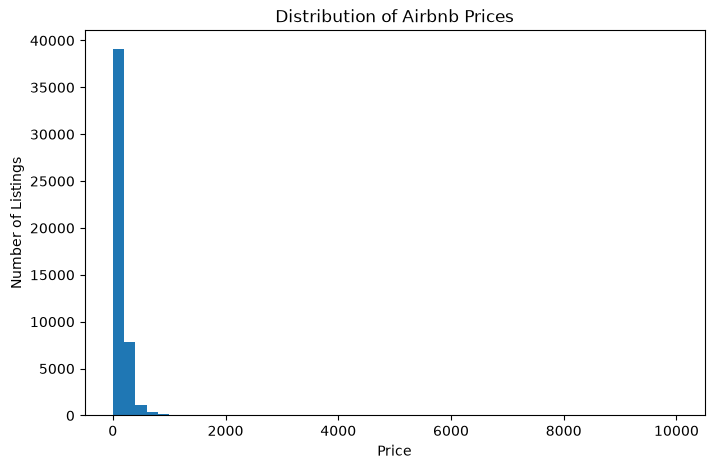

In [11]:
import matplotlib.pyplot as plt

# Plot the distribution of price
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Airbnb Prices")
plt.show()

### 1.9 Correlation Analysis

Correlation analysis helps us understand the relationship between numerical variables and the target variable `price`.

In [12]:
# Calculate correlations with price
correlation_with_price = (
    df[numerical_columns]
    .corr()["price"]
    .sort_values(ascending=False)
)

print("Correlation with Price:")
display(correlation_with_price)

Correlation with Price:


price                             1.000000
availability_365                  0.081829
calculated_host_listings_count    0.057472
minimum_nights                    0.042799
latitude                          0.033939
host_id                           0.015309
id                                0.010619
reviews_per_month                -0.030608
number_of_reviews                -0.047954
longitude                        -0.150019
Name: price, dtype: float64

### 1.10 Price by Room Type

Room type is an important categorical feature because different types of accommodation may have different price levels.

In [13]:
# Compare price statistics across room types
room_type_price = (
    df.groupby("room_type")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(room_type_price)

,count,mean,median
room_type,,,
Entire home/apt,25409,211.794246,160.0
Private room,22326,89.780973,70.0
Shared room,1160,70.127586,45.0


### 1.11 Price by Neighbourhood Group

Neighbourhood location can strongly influence Airbnb prices. We compare price statistics across neighbourhood groups.

In [14]:
# Compare price statistics across neighbourhood groups
neighbourhood_price = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(neighbourhood_price)

,count,mean,median
neighbourhood_group,,,
Manhattan,21661,196.875814,150.0
Brooklyn,20104,124.383207,90.0
Staten Island,373,114.812332,75.0
Queens,5666,99.517649,75.0
Bronx,1091,87.496792,65.0


### 1.12 Outlier Analysis

Outliers are unusually high or low values that may affect statistical analysis and model performance. We examine the numerical variables for potential outliers.

In [15]:
# Calculate the number of outliers using the IQR method
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

outlier_counts = (
    ((df[numerical_columns] < (Q1 - 1.5 * IQR)) |
     (df[numerical_columns] > (Q3 + 1.5 * IQR)))
    .sum()
    .sort_values(ascending=False)
)

print("Number of Outliers:")
display(outlier_counts)

Number of Outliers:


calculated_host_listings_count    7081
minimum_nights                    6607
number_of_reviews                 6021
price                             2972
longitude                         2833
reviews_per_month                 1793
host_id                           1526
latitude                           425
id                                   0
availability_365                     0
dtype: int64

### 1.13 Data Cleaning

Based on the missing-value and outlier analysis, we now prepare the dataset for modeling.

We will:
- Handle missing values in important columns.
- Remove duplicate records if present.
- Keep the original `price` column as the target variable.
- Avoid removing all outliers automatically because some high Airbnb prices may represent genuine listings.

In [16]:
# Create a copy for data cleaning
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

print("\nRemaining Missing Values:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Original Shape: (48895, 16)
Cleaned Shape: (48895, 16)

Remaining Missing Values:


name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

### 1.13 Remove Unnecessary Columns

Some columns identify the listing or host but do not provide useful information for predicting price. These columns will be removed before modeling.

In [17]:


# Remove identifier and text columns that are not needed for prediction
columns_to_drop = [
    "id",
    "name",
    "host_id",
    "host_name"
]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Shape after removing unnecessary columns:", df_clean.shape)
print("\nRemaining Columns:")
print(df_clean.columns.tolist())

# Fill missing review counts with 0
# No reviews means zero reviews per month
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

print("Remaining missing values:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Shape after removing unnecessary columns: (48895, 12)

Remaining Columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Remaining missing values:


last_review    10052
dtype: int64

### 1.14 Define Features and Target

The `price` column is the target variable that we want to predict.

All remaining columns are used as input features.

In [18]:
# Define features (X) and target (y)
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget variable:")
print(y.name)

Features shape: (48895, 11)
Target shape: (48895,)

Target variable:
price


### 1.15 Feature Engineering

Additional features are created to capture location, review activity, and host characteristics that may influence Airbnb prices.

The following features are engineered:

- `distance_to_midtown`: Approximate distance of the listing from Midtown/Times Square.
- `has_reviews`: Indicates whether the listing has received at least one review.
- `log_number_of_reviews`: Log-transformed number of reviews to reduce the effect of extreme review counts.
- `is_commercial_host`: Indicates whether the host manages more than one listing.
- `days_since_last_review`: Number of days since the listing's most recent review.

These features provide additional information about location, customer activity, and host behavior that may help the prediction models.

In [19]:
# Import NumPy
import numpy as np

# -------------------------------------------------------------
# 1. Location Feature
# -------------------------------------------------------------

# Coordinates for Midtown / Times Square
midtown_lat = 40.7580
midtown_lon = -73.9855

# Calculate approximate distance from Midtown
df_clean["distance_to_midtown"] = np.sqrt(
    (df_clean["latitude"] - midtown_lat) ** 2 +
    (df_clean["longitude"] - midtown_lon) ** 2
)


# -------------------------------------------------------------
# 2. Review Features
# -------------------------------------------------------------

# Indicates whether the listing has received any reviews
df_clean["has_reviews"] = (
    df_clean["number_of_reviews"] > 0
).astype(int)

# Log-transform number of reviews
df_clean["log_number_of_reviews"] = np.log1p(
    df_clean["number_of_reviews"]
)


# -------------------------------------------------------------
# 3. Host Feature
# -------------------------------------------------------------

# Hosts with more than one listing are treated as commercial hosts
df_clean["is_commercial_host"] = (
    df_clean["calculated_host_listings_count"] > 1
).astype(int)


# -------------------------------------------------------------
# 4. Review Recency Feature
# -------------------------------------------------------------

# Convert last_review to datetime
df_clean["last_review"] = pd.to_datetime(
    df_clean["last_review"]
)

# Fixed reference date
reference_date = pd.Timestamp("2019-12-31")

# Calculate days since the most recent review
df_clean["days_since_last_review"] = (
    reference_date - df_clean["last_review"]
).dt.days

# -1 indicates that the listing has no review history
df_clean["days_since_last_review"] = (
    df_clean["days_since_last_review"]
    .fillna(-1)
)

# Remove the original date column
df_clean = df_clean.drop(columns=["last_review"])


# -------------------------------------------------------------
# 5. Verify Engineered Features
# -------------------------------------------------------------

engineered_features = [
    "distance_to_midtown",
    "has_reviews",
    "log_number_of_reviews",
    "is_commercial_host",
    "days_since_last_review"
]

print("Engineered Features:")
display(df_clean[engineered_features].head(10))

print("\nEngineered Feature Statistics:")
display(df_clean[engineered_features].describe())

Engineered Features:


,distance_to_midtown,has_reviews,log_number_of_reviews,is_commercial_host,days_since_last_review
0,0.111287,1,2.302585,1,438.0
1,0.004709,1,3.828641,1,224.0
2,0.067112,0,0.000000,0,-1.0
3,0.077273,1,5.602119,0,179.0
4,0.058001,1,2.302585,0,407.0
5,0.014730,1,4.317488,0,192.0
6,0.077011,1,3.912023,0,817.0
7,0.006914,1,6.066108,0,190.0
8,0.047439,1,4.779123,0,893.0
9,0.044825,1,5.081404,1,205.0



Engineered Feature Statistics:


,distance_to_midtown,has_reviews,log_number_of_reviews,is_commercial_host,days_since_last_review
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,0.070488,0.794417,1.990775,0.339339,359.605890
std,0.045720,0.404131,1.564185,0.473490,412.015494
min,0.000677,0.000000,0.000000,0.000000,-1.000000
25%,0.037097,1.000000,0.693147,0.000000,180.000000
50%,0.065278,1.000000,1.791759,0.000000,200.000000
75%,0.091743,1.000000,3.218876,1.000000,422.000000
max,0.363140,1.000000,6.445720,1.000000,3200.000000


### 1.15.1 Target Transformation

The original `price` column is retained because it represents the actual Airbnb price in dollars.

Since `price` is highly right-skewed, we create `log_price` using a logarithmic transformation. This reduces the effect of extreme prices and can improve model performance.

`log_price` is a transformed target variable and is not used as an input feature.

In [20]:
# Create a log-transformed version of the target variable
df_clean["log_price"] = np.log1p(df_clean["price"])

# Compare the original and transformed target
print("Original Price:")
display(df_clean["price"].describe())

print("\nLog-transformed Price:")
display(df_clean["log_price"].describe())

Original Price:


count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


Log-transformed Price:


count    48895.000000
mean         4.736885
std          0.695344
min          0.000000
25%          4.248495
50%          4.672829
75%          5.170484
max          9.210440
Name: log_price, dtype: float64

In [21]:
print(df_clean.columns.tolist())

['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'distance_to_midtown', 'has_reviews', 'log_number_of_reviews', 'is_commercial_host', 'days_since_last_review', 'log_price']


### 1.16 Define Final Features and Target

The target variable is `price`.

All selected numerical, categorical, and engineered features are used as input variables for prediction.

The original `price` column is kept separately as the target and is not included in the input features.

In [22]:
# Define the input features
features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "distance_to_midtown",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_reviews",
    "log_number_of_reviews",
    "days_since_last_review",
    "is_commercial_host"
]

# Create X
X = df_clean[features]

# Define original and transformed targets
y_price = df_clean["price"]
y_log_price = df_clean["log_price"]

# Identify categorical features
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Identify numerical features
numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

print("\nTotal Input Features:", len(features))

Categorical Features:
['neighbourhood_group', 'neighbourhood', 'room_type']

Numerical Features:
['latitude', 'longitude', 'distance_to_midtown', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'log_number_of_reviews', 'days_since_last_review', 'is_commercial_host']

Total Input Features: 15


C:\Users\kau_shal\AppData\Local\Temp\ipykernel_21408\1343821686.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


### 1.17 Stratified Train-Test Split

The `price` variable is highly skewed, so a simple random split may produce slightly different price distributions in the training and testing sets.

To maintain a similar distribution of prices in both sets, we create price bins and use stratified sampling.

In [23]:
from sklearn.model_selection import train_test_split

# Define features
X = df_clean[features]

# Use log_price as the modeling target
y = df_clean["log_price"]

# Create price bins from original price for stratification
price_bins = pd.qcut(
    df_clean["price"],
    q=5,
    labels=False,
    duplicates="drop"
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=price_bins
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (39116, 15)
X_test: (9779, 15)
y_train: (39116,)
y_test: (9779,)


In [24]:

print("X_train columns:")
print(X_train.columns.tolist())

print("\nX_test columns:")
print(X_test.columns.tolist())

print("\nCurrent X columns:")
print(X.columns.tolist())

X_train columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'distance_to_midtown', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'log_number_of_reviews', 'days_since_last_review', 'is_commercial_host']

X_test columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'distance_to_midtown', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'log_number_of_reviews', 'days_since_last_review', 'is_commercial_host']

Current X columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'distance_to_midtown', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'log_number_of_reviews', 'days_since_last_review', 'is_commercial_host']


### 1.18 Preprocessing

The numerical features have already been cleaned during data preparation, so only standardization is required for numerical variables.

Categorical features are converted into numerical form using one-hot encoding. 
`handle_unknown='ignore'` ensures that categories appearing in the test data but not in the training data do not cause errors.

A `ColumnTransformer` applies the appropriate transformation to each feature type.

In [25]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine numerical and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Preprocessor created successfully.

Numerical features:
['latitude', 'longitude', 'distance_to_midtown', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'log_number_of_reviews', 'days_since_last_review', 'is_commercial_host']

Categorical features:
['neighbourhood_group', 'neighbourhood', 'room_type']


### 1.19 Linear Regression

Linear Regression is used as the baseline model for predicting Airbnb prices.

The preprocessing steps are combined with Linear Regression in a single pipeline. This ensures that the same feature transformations are applied during both training and prediction.

In [26]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression pipeline
linear_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the model
linear_regression_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 1.20 Model Evaluation — Linear Regression

The Linear Regression model is evaluated using three standard regression metrics:

* **MAE (Mean Absolute Error):** average absolute difference between actual and predicted prices.
* **RMSE (Root Mean Squared Error):** gives more weight to larger prediction errors.
* **R² Score:** measures how much variation in the target is explained by the model.

Since the model was trained on `log_price`, predictions are converted back to the original price scale using `np.expm1()` before calculating the metrics.


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict log prices
y_pred_log = linear_regression_model.predict(X_test)

# Convert predictions back to original price scale
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("Linear Regression Performance")
print(f"MAE  : ${mae:.2f}")
print(f"RMSE : ${rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
MAE  : $57.49
RMSE : $192.48
R²   : 0.1406


### 1.21 Random Forest Regression

Random Forest Regression is an ensemble learning method that combines multiple decision trees to make predictions.

Unlike Linear Regression, Random Forest can capture non-linear relationships between features and Airbnb prices. This makes it useful for comparing whether a more flexible model improves prediction performance.


In [28]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['neighbourhood_group','neighbourhood','latitude',..., 'log_number_of_reviews','days_since_last_review','is_commercial_host']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will b

### 1.22 Model Evaluation — Random Forest

The Random Forest model is evaluated using MAE, RMSE, and R² on the original Airbnb price scale.

The predictions are converted from `log_price` back to actual prices before calculating the metrics.


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict log prices
y_pred_rf_log = random_forest_model.predict(X_test)

# Convert back to original price scale
y_pred_rf = np.expm1(y_pred_rf_log)
y_actual = np.expm1(y_test)

# Calculate metrics
rf_mae = mean_absolute_error(y_actual, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_actual, y_pred_rf))
rf_r2 = r2_score(y_actual, y_pred_rf)

print("Random Forest Performance")
print(f"MAE  : ${rf_mae:.2f}")
print(f"RMSE : ${rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
MAE  : $54.36
RMSE : $185.01
R²   : 0.2060


Hyperparameter Tuning — Random Forest

Hyperparameter tuning is used to find better settings for the Random Forest model.

The main parameters tuned are:

n_estimators: number of decision trees.
max_depth: maximum depth of each tree.
min_samples_split: minimum samples required to split a node.
min_samples_leaf: minimum samples required in a leaf.

RandomizedSearchCV tests different combinations using cross-validation and selects the combination with the best performance.

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ))
])

# Small parameter grid for faster execution
param_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Grid Search with 2-fold cross-validation
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=6,
    verbose=1
)



In [45]:
rf_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid_search.best_params_)

print("\nBest CV RMSE:")
print(-rf_grid_search.best_score_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Best CV RMSE:
0.4460305780068343


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Get the best model found by GridSearchCV
best_rf_model = rf_grid_search.best_estimator_

# Predict using the TUNED model
y_pred_rf_tune_log = best_rf_model.predict(X_test)

# Convert back to original price
y_pred_rf_tune = np.expm1(y_pred_rf_tune_log)
y_actual = np.expm1(y_test)

# Calculate tuned model metrics
rf_mae_tune = mean_absolute_error(y_actual, y_pred_rf_tune)
rf_rmse_tune = np.sqrt(mean_squared_error(y_actual, y_pred_rf_tune))
rf_r2_tune = r2_score(y_actual, y_pred_rf_tune)

print("Tuned Random Forest")
print("-------------------")
print(f"MAE  : {rf_mae_tune:.2f}")
print(f"RMSE : {rf_rmse_tune:.2f}")
print(f"R²   : {rf_r2_tune:.4f}")

Tuned Random Forest
-------------------
MAE  : 53.60
RMSE : 186.57
R²   : 0.1926


### 1.23 XGBoost Regression

XGBoost (Extreme Gradient Boosting) is an ensemble learning algorithm that builds decision trees sequentially, with each new tree helping to correct errors made by previous trees.

It can model complex non-linear relationships and interactions between Airbnb features, making it a strong candidate for price prediction.


In [37]:
from xgboost import XGBRegressor

xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
xgboost_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### 1.24 Model Evaluation — XGBoost

The XGBoost model is evaluated using MAE, RMSE, and R² on the original Airbnb price scale.

The predicted log prices are converted back to dollar prices before calculating the evaluation metrics.


In [31]:
# Predict log prices
y_pred_xgb_log = xgboost_model.predict(X_test)

# Convert back to original price scale
y_pred_xgb = np.expm1(y_pred_xgb_log)

# Calculate metrics
xgb_mae = mean_absolute_error(y_actual, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_actual, y_pred_xgb))
xgb_r2 = r2_score(y_actual, y_pred_xgb)

print("XGBoost Performance")
print(f"MAE  : ${xgb_mae:.2f}")
print(f"RMSE : ${xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
MAE  : $53.86
RMSE : $188.21
R²   : 0.1784


hyperameter tunning

In [35]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

# XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        random_state=42,
        n_jobs=1
    ))
])

# Small parameter grid
param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.05, 0.1]
}

# Grid Search
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=2,
    scoring="neg_root_mean_squared_error",
    n_jobs=4,
    verbose=1
)

# Fit GridSearchCV
xgb_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_grid_search.best_params_)

print("\nBest CV RMSE:")
print(-xgb_grid_search.best_score_)

Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200}

Best CV RMSE:
0.44445071602058783


In [38]:
import joblib
import os

# Select the best XGBoost model from GridSearchCV
final_model = xgboost_model

# Save the complete pipeline with compression
joblib.dump(
    final_model,
    "airbnb_xgboost_model.joblib",
    compress=3
)

# Check file size
file_size_mb = os.path.getsize("airbnb_xgboost_model.joblib") / (1024 ** 2)

print("Final XGBoost model saved successfully.")
print(f"Model size: {file_size_mb:.2f} MB")

Final XGBoost model saved successfully.
Model size: 0.25 MB


In [40]:
loaded_model = joblib.load("airbnb_xgboost_model.joblib")

print("Model loaded successfully.")
print(loaded_model)

Model loaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'distance_to_midtown',
                                                   'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365',
                                                   'has_reviews',
                                                   'log_number_of_reviews',
                                                   'days_